
# TP 14: Predicting dynamics with Neural-ODE

**The goal of this pratical is use machine learning models to predict the
evolution of dynamical systems driven by physical laws, *e.g.* ordinary
Differential Equations (ODE).**

Let us considers a physcial system in Newtonian mechanichs composed of a
**damped pendulum**, with length $l$ and mass $m$, and $\theta$ being the
angle with respect to the vertical direction:

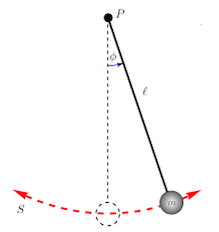

**Let us denote $\dot{\theta_t}:=\frac{d\theta}{dt}$ and
$\ddot{\theta}_t:=\frac{d^2\theta}{dt^2}$ as the first and second temporal
derivatives of $\theta$.** The dynamics of the pendulum is driven by the
following ODE on $\theta$:

\begin{equation} \ddot{\theta_t} + \omega_0^2~ sin\left(\theta_t\right) +
\alpha \dot{\theta}_t = 0 \end{equation}

where $\omega_0 = \sqrt{\frac{g}{\ell}}$ ($g$ is the gravitational constant, i.e. $9.8 ms^{-2}$), $\ell$ is the length of the rod,
and $\alpha = \frac{k}{ml^2}$ is the friction coefficient.

In the general case, the ODE does not have a closed-form
solution. Let us denote as $\mathbf{Y}_t=(\theta_t, \dot{\theta}_t)$ the 2d
state vector of the pendulum.



**<u>Question 1:</u> show that
 $\dot{\mathbf{Y}_t}=f\left({\mathbf{Y}_t}\right)$, *i.e* that the evolution
 of $\mathbf{Y}$ follows a first-order ODE. Give the expression of f.**


From a given initial condition $\mathbf{Y}_0=(\theta_0, \dot{\theta}_0)$, we
can estimate the state vector $\mathbf{Y}_t$ at any time $t$:

\begin{equation} \mathbf{Y}_t = \mathbf{Y}_0 + \int_0^t \dot{\mathbf{Y}_t} ~dt
= \mathbf{Y}_0 + \int_0^t f\left(\mathbf{Y}_t\right) dt
\end{equation}

where $f\left( \mathbf{Y}_t \right)$ only depends on the current state
$\mathbf{Y}_t$ at time $t$. The integral can be approximated
with numerical schemes. The Euler method is simplest one (see figure below):
starting from $\mathbf{Y}_0$, we have $\mathbf{Y}_{t+1} = \mathbf{Y}_{t} +
f\left(\mathbf{Y}_t\right)$ $\forall t>1$. The has been extensive studies for
developing improved numerical solvers in the last centuries, e.g. different
orders of Runge-Kutta solvers.

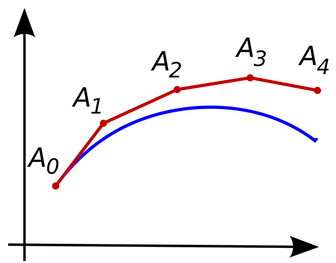


## Required Packages

Before starting, please ensure you have the following packages installed:

**Core packages:**
- `torch` (>=1.12) - PyTorch for deep learning
- `torchdiffeq` - ODE solvers for PyTorch (install with: `pip install torchdiffeq`)
- `scipy` - Scientific computing library (for `solve_ivp`)
- `numpy` - Numerical computing
- `matplotlib` - Plotting and visualization

**Installation commands:**
- **Conda:** `conda install pytorch scipy numpy matplotlib -c pytorch && pip install torchdiffeq`
- **Pip:** `pip install torch torchdiffeq scipy numpy matplotlib`

In [ ]:
# For Google Colab users: Run this cell to install required packages
!pip install torch torchdiffeq scipy numpy matplotlib


## Part I. Generating damped pendulum simulations
First, lets do some import

In [ ]:
import math
import os

# Fix OpenMP library conflict on macOS (common issue with PyTorch)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
from scipy.integrate import solve_ivp

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
from torch import optim

from torchdiffeq import odeint_adjoint, odeint  # odeint_adjoint used in commented line for students

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [20, 10]

# Device selection: prefer MPS (Apple Silicon) > CUDA > CPU
# Note: MPS can be unstable in some environments, use CPU if issues occur
try:
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
except Exception as e:
    # Fallback to CPU if device selection fails
    print(f"Warning: Device selection failed ({e}), using CPU")
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [ ]:

import os

if os.environ.get("TESTING_MODE", "off") == "ON":
    # Reduce parameters for faster testing
    num_seq = 5
    time_horizon = 10
    n_hidden = 50
    n_epochs = 10
    plt.show = lambda *args, **kwargs: None

### I.a) DampedPendulum

**We will write a DampedPendulum Dataset, which simulates different pendulum trajectories from differents initial conditions. Fill the code in the code in the following DampedPendulum class. We use the following setting:** $\omega_0= \frac{\Pi}{3}$, $\alpha= 0.2$ , with $dt=0.5$

You have to fill the `__init__` and `_compute_trajectory` functions. For `_compute_trajectory`, the goal is to simulate a given trajectory from an initial condition:
- The function `_get_initial_condition` is provided
- To perform the simulation in `_compute_trajectory`, you need to:
    - Call the `_get_initial_condition`
    - Call the solver: we will use the solve_ivp method from from `scipy.integrate`, using the 'DOP853' method (Explicit Runge-Kutta method of order 8).
- Since the simulation is computationally demanding, the class below uses a cache to store each trajectory

In [ ]:
class DampedPendulum(Dataset):
    def __init__(self, num_seq: int, time_horizon: int, dt: float):
        """Creates a new dataset of trajectories

        :param num_seq: Size of the dataset
        :param time_horizon: _description_
        :param dt: _description_
        """
        super().__init__()

        # ici c mon code
        self.omega0_square = (math.pi / 3) ** 2
        self.alpha = 0.2
        self.len = num_seq
        self.time_horizon = time_horizon

        # This caches the trajectories so we compute them once only
        self.data = [None] * num_seq

        self.t_eval = torch.arange(0, self.time_horizon, float(dt))

    def __getitem__(self, index: int):
        if self.data[index] is None:
            self.data[index] = torch.tensor(self._compute_trajectory(), dtype=torch.float32)
        return {"states": self.data[index], "t": self.t_eval}

    def __len__(self):
        return len(self.data)

    def _get_initial_condition(self):
        """Returns the vector of initial conditions"""
        y0 = np.random.randn(2) * 2.0 - 1
        r = np.random.rand() + 1.3
        y0 = y0 / np.sqrt((y0**2).sum()) * r

        return y0

    def _get__state_derivative(self, t, x):  # coords = [q,p].
        dq_dt = x[1]  # theta_dot
        dp_dt = -self.omega0_square * np.sin(x[0]) - self.alpha * x[1]  # theta_2dot
        return [dq_dt, dp_dt]

    def _compute_trajectory(self):
        y0 = self._get_initial_condition()
        t_eval_np = self.t_eval.numpy().astype(float)
        sol = solve_ivp(self._get__state_derivative,
                        [self.t_eval[0].item(), self.t_eval[-1].item()],
                        y0,
                        method='DOP853',
                        t_eval=t_eval_np)
        states = sol.y.T # je  veux avoir un shape de time_steps, dimensions
        return states


### I.b) Train/test data generation

**We can now define train and test dataloader** (use 25 train/test sequences
with a batch size of 25). **Plot the resulting trajectories ($\theta$ and
optionally $\dot{\theta}$).**

In [ ]:
# path = "./exp2/pendulum/pendulum"

# Default parameters (can be overridden by TESTING_MODE)
if 'num_seq' not in locals():
    num_seq = 25
if 'time_horizon' not in locals():
    time_horizon = 20
dt = 0.5
dataset_train = DampedPendulum(num_seq, time_horizon, dt)
dataset_test = DampedPendulum(num_seq, time_horizon, dt)


batch_size = 25

train_loader = DataLoader(
    dataset=dataset_train,
    batch_size=batch_size,
    num_workers=0,
    pin_memory=True,
    drop_last=False,
    shuffle=True,
)
test_loader = DataLoader(
    dataset=dataset_test,
    batch_size=batch_size,
    num_workers=0,
    pin_memory=True,
    drop_last=False,
    shuffle=False,
)

In [ ]:
# Show one item of the dataset

dataset_train[0]


{'states': tensor([[-1.0824,  1.6187],
         [-0.2189,  1.7706],
         [ 0.6146,  1.4937],
         [ 1.2263,  0.9330],
         [ 1.5417,  0.3315],
         [ 1.5669, -0.2218],
         [ 1.3291, -0.7184],
         [ 0.8650, -1.1130],
         [ 0.2543, -1.2803],
         [-0.3616, -1.1258],
         [-0.8290, -0.7195],
         [-1.0653, -0.2214],
         [-1.0539,  0.2594],
         [-0.8194,  0.6587],
         [-0.4214,  0.9000],
         [ 0.0421,  0.9105],
         [ 0.4502,  0.6911],
         [ 0.7096,  0.3326],
         [ 0.7777, -0.0583],
         [ 0.6593, -0.4014],
         [ 0.3957, -0.6283],
         [ 0.0594, -0.6856],
         [-0.2597, -0.5643],
         [-0.4835, -0.3155],
         [-0.5672, -0.0181],
         [-0.5056,  0.2552],
         [-0.3262,  0.4445],
         [-0.0823,  0.5080],
         [ 0.1592,  0.4371],
         [ 0.3375,  0.2630],
         [ 0.4143,  0.0416],
         [ 0.3810, -0.1684],
         [ 0.2560, -0.3183],
         [ 0.0784, -0.3752],
    

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


torch.Size([25, 40, 2])


<Figure size 2000x1000 with 0 Axes>

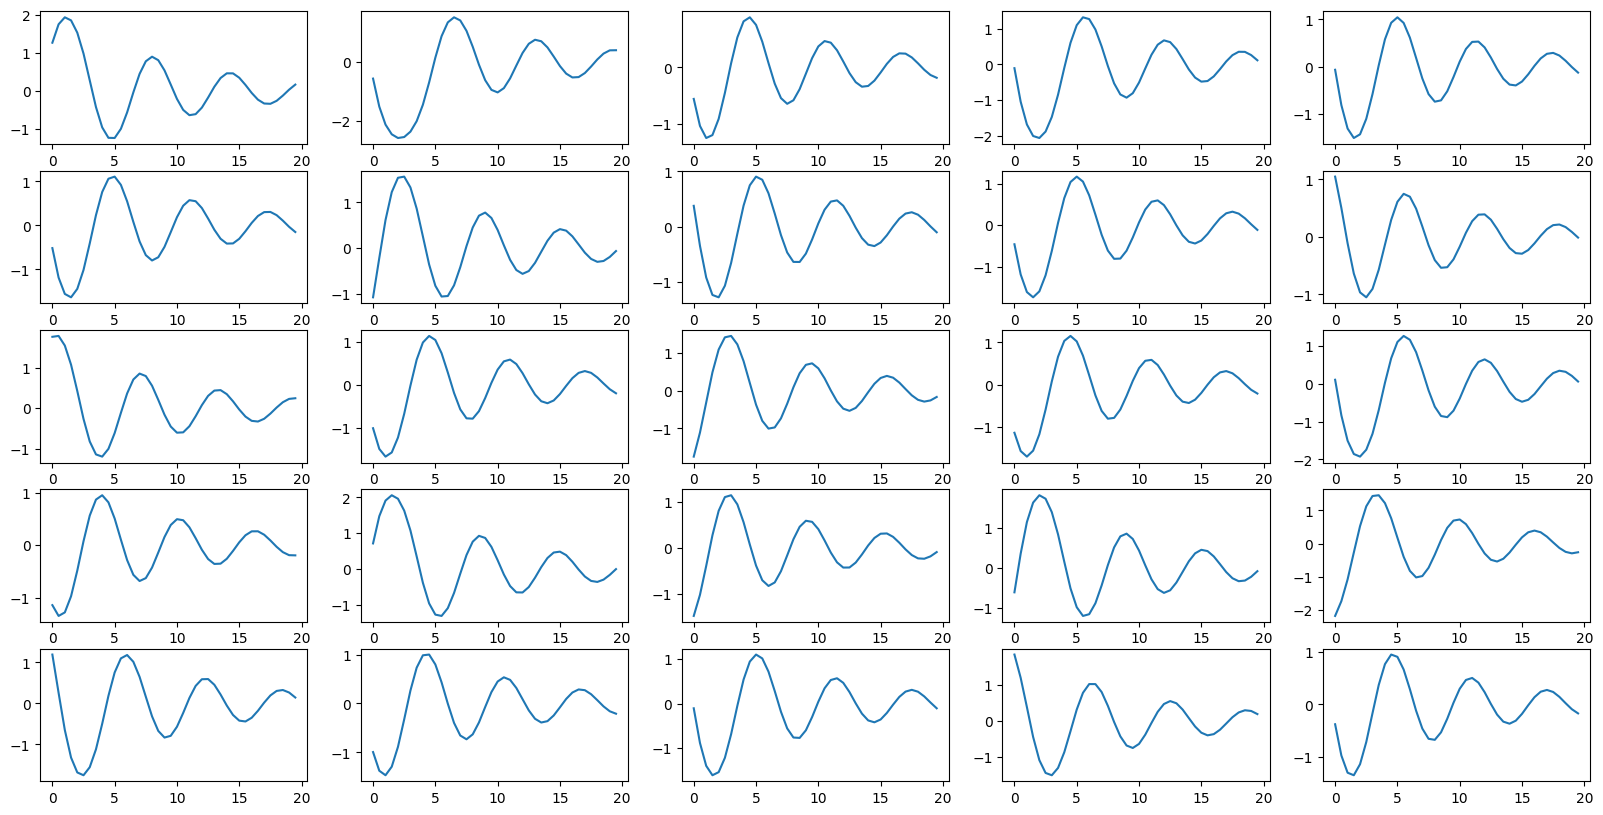

In [ ]:
data = next(iter(train_loader))
# je rappel aussi que: data["states"].shape = (batch_size, T, d) = ([25, 40, 2])
print(data["states"].shape)
draw_dottheta = False

plt.figure()
plt.rcParams["figure.figsize"] = [20, 10]

# Determine grid size based on batch size
batch_size = data["states"].shape[0]
grid_size = min(int(np.ceil(np.sqrt(batch_size))), 5)
fig, axs = plt.subplots(grid_size, grid_size)

for i in range(grid_size):
    for j in range(grid_size):
        idx = i * grid_size + j
        if idx < batch_size:
            axs[i, j].plot(data["t"][idx], data["states"][idx, :, 0])


if draw_dottheta:
    fig, axs = plt.subplots(grid_size, grid_size)
    for i in range(grid_size):
        for j in range(grid_size):
            idx = i * grid_size + j
            if idx < batch_size:
                axs[i, j].plot(data["t"][idx], data["states"][idx, 1, :])

<Figure size 2000x1000 with 0 Axes>

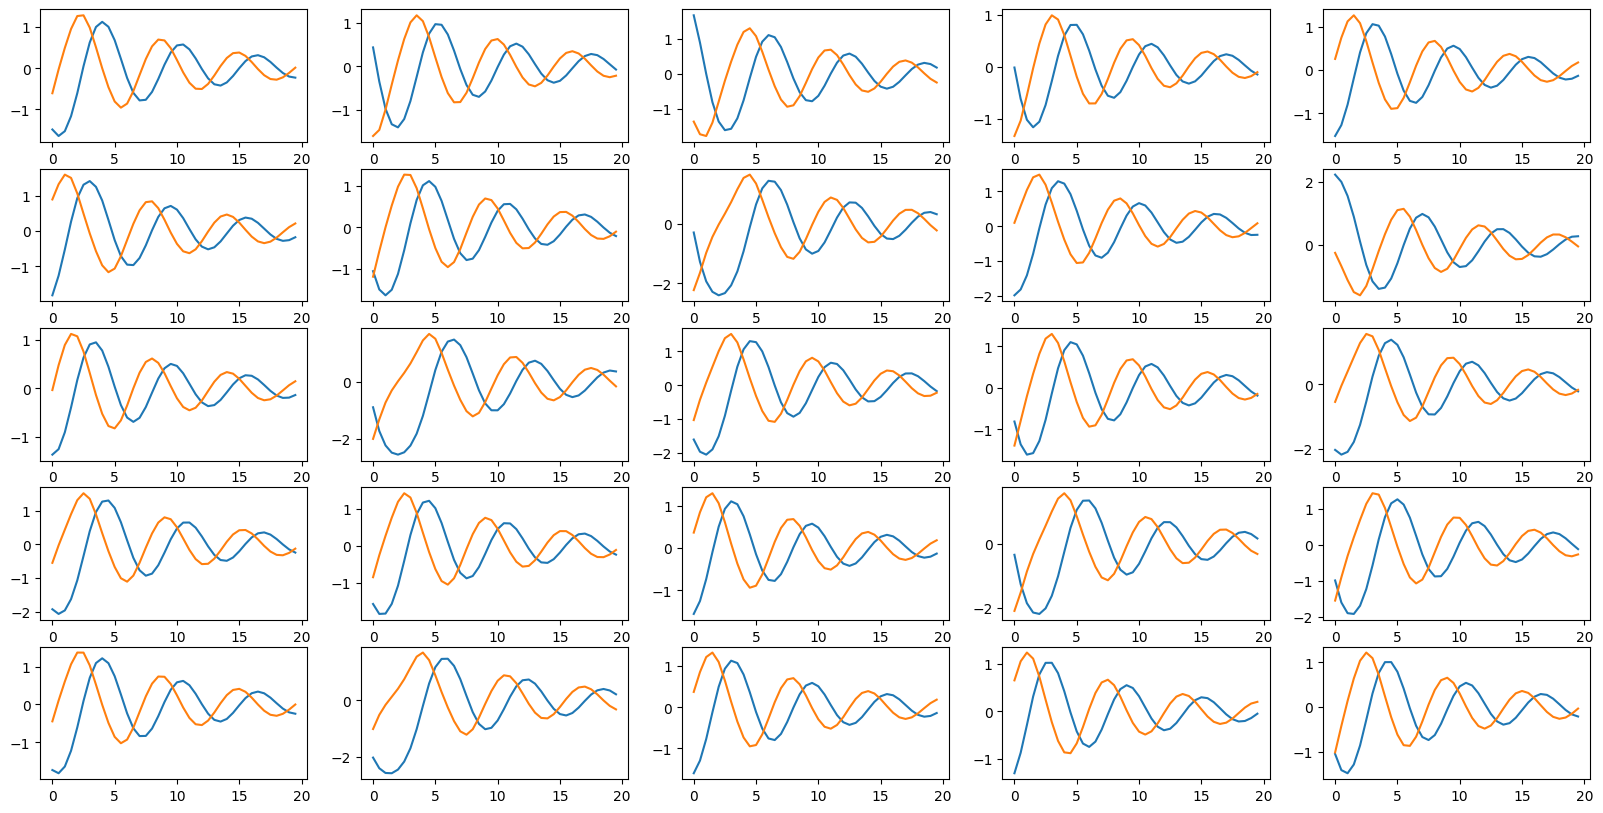

In [ ]:
data_test = next(iter(test_loader))

plt.figure()
plt.rcParams["figure.figsize"] = [20, 10]

# Determine grid size based on batch size
batch_size_test = data_test["states"].shape[0]
grid_size_test = min(int(np.ceil(np.sqrt(batch_size_test))), 5)
fig, axs = plt.subplots(grid_size_test, grid_size_test)
draw_dottheta = True

for i in range(grid_size_test):
    for j in range(grid_size_test):
        idx = i * grid_size_test + j
        if idx < batch_size_test:
            axs[i, j].plot(data_test["t"][idx], data_test["states"][idx, :, 0])

if draw_dottheta:
    for i in range(grid_size_test):
        for j in range(grid_size_test):
            idx = i * grid_size_test + j
            if idx < batch_size_test:
                axs[i, j].plot(
                    data_test["t"][idx], data_test["states"][idx, :, 1]
                )




### Plot initial condition distribution

In [ ]:
print(data["states"].shape)
print(data_test["states"].shape)

torch.Size([25, 40, 2])
torch.Size([25, 40, 2])


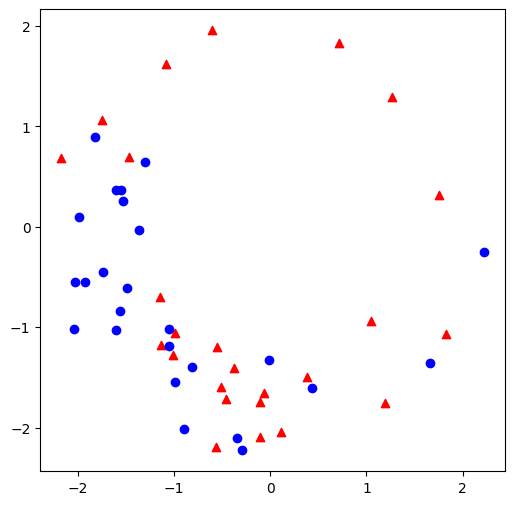

In [ ]:
theta0_train = data["states"][:, 0, 0]
dtheta0_train = data["states"][:, 0, 1]

theta0_test = data_test["states"][:, 0, 0]
dtheta0_test = data_test["states"][:, 0, 1]

plt.figure(figsize=(6, 6))
plt.scatter(theta0_train, dtheta0_train,
            marker="^", c="red", label="Train")
plt.scatter(theta0_test, dtheta0_test,
            c="blue", label="Test")


## 2) Predicting trajectories with Neural-ODE

The goal is to use the Neural-ODE method [1] to predict the future trajectory
from an initial condition. **More precisely, the idea is to define a
parametric model, *e.g.* an neural network, to predict the state's derivative
from the current state value:
$\dot{\mathbf{Y}_t}=f_{\theta}\left({\mathbf{Y}_t}\right)$, with $\theta$
being the neural net parameters. From an initial condition $\mathbf{Y}_0$ and
$f_{\theta}\left({\mathbf{Y}_t}\right)$, we can then use Equation below to
predict the full predicted trajectory $\hat{\mathbf{Y}}$. The goal is to
optimize $\theta$ parameters such that predicted trajectories are close to the
GT trajectories in the training set.**

\begin{equation} \hat{\mathbf{Y}_t}  = \mathbf{Y}_0 + \int_0^t
f_{\theta}\left(\mathbf{Y}_t\right) dt \end{equation}


**Let's fill the DerivativeEstimator class to predict the the state's
derivative.** We will use a simple MLP (2 hidden layers + ReLU) for prediction
since the state is a 2D vector.


In [ ]:
class DerivativeEstimator(nn.Module):
    def __init__(self, n_state: int, n_hidden: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_state, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_state)
        )

    def forward(self, t, state):
        return self.net(state)


**The forecaster will perform the prediction from a initial state $y_0$**. To
perform the numerical integration, we use the [`odeint` method from
torchdiffeq](https://github.com/rtqichen/torchdiffeq). We will use the generic
'rk4' solver to perform numerical integration. **Fill the following Forecaster
class with:**
- A constructor creating a reference to an DerivativeEstimator instance
- the forward method calls the `odeint` method to perform integration from an
  initial $y_0$ state. **N.B.**: the output dimensions after calling `odeint`
  will be `T x batch_size x n_c`, swap them to fit the requested Pytorch
  standard (`batch_size x n_c X T`)

In [ ]:
from torchdiffeq import odeint

class Forecaster(nn.Module):
    def __init__(self, n_state, n_hidden, method="rk4"):
        super().__init__()
        self.derivative_estimator = DerivativeEstimator(n_state, n_hidden)
        self.method = method

    def forward(self, y0: torch.Tensor, t: torch.Tensor):
        pred_y = odeint(
            self.derivative_estimator,
            y0,
            t,
            method=self.method
        )

        pred_y = pred_y.permute(1, 2, 0)
        return pred_y  # (B, N_c, T)



### Write the training loop!

For each batch:
- Get the first state of each training trajectory
- Perform prediction of the forecaster for each time step of the horizon
- We will use a simple MSE loss between the ground truth and predicted
  trajectories.
- Use an Adam optimizer (default paramters)
- Plot the train / test trajectories

In [ ]:
n_state = 2

if 'n_hidden' not in locals():
    n_hidden = 200
if 'n_epochs' not in locals():
    n_epochs = 1001

forecaster_net = Forecaster(n_state, n_hidden, method="rk4").to(device)

optimizer = optim.Adam(forecaster_net.parameters(), lr=1e-3)
traj_loss = nn.MSELoss()

from tqdm import tqdm

for e in tqdm(range(n_epochs)):
    epoch_loss = 0.0

    for data_batch in train_loader:
        optimizer.zero_grad()
        states = data_batch["states"].to(device)  # B x T x N_c
        t = data_batch["t"][0].to(device).float() # T (float!)

        y0 = states[:, 0, :]  # B x N_c
        pred_y = forecaster_net(y0, t)  # B x N_c x T
        gt_y = states.permute(0, 2, 1)
        loss = traj_loss(pred_y, gt_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if e % 100 == 0:
        print(f"Epoch {e}/{n_epochs}, Loss: {epoch_loss / len(train_loader):.6f}")


  0%|          | 2/1001 [00:00<01:45,  9.49it/s]

Epoch 0/1001, Loss: 2.886253


 10%|█         | 102/1001 [00:20<01:42,  8.75it/s]

Epoch 100/1001, Loss: 0.028207


 20%|██        | 202/1001 [00:32<02:15,  5.88it/s]

...

Epoch 800/1001, Loss: 0.000058


 90%|█████████ | 902/1001 [02:00<00:10,  9.29it/s]

Epoch 900/1001, Loss: 0.002513


100%|██████████| 1001/1001 [02:12<00:00,  7.56it/s]

Epoch 1000/1001, Loss: 0.000038


<Figure size 2000x1000 with 0 Axes>

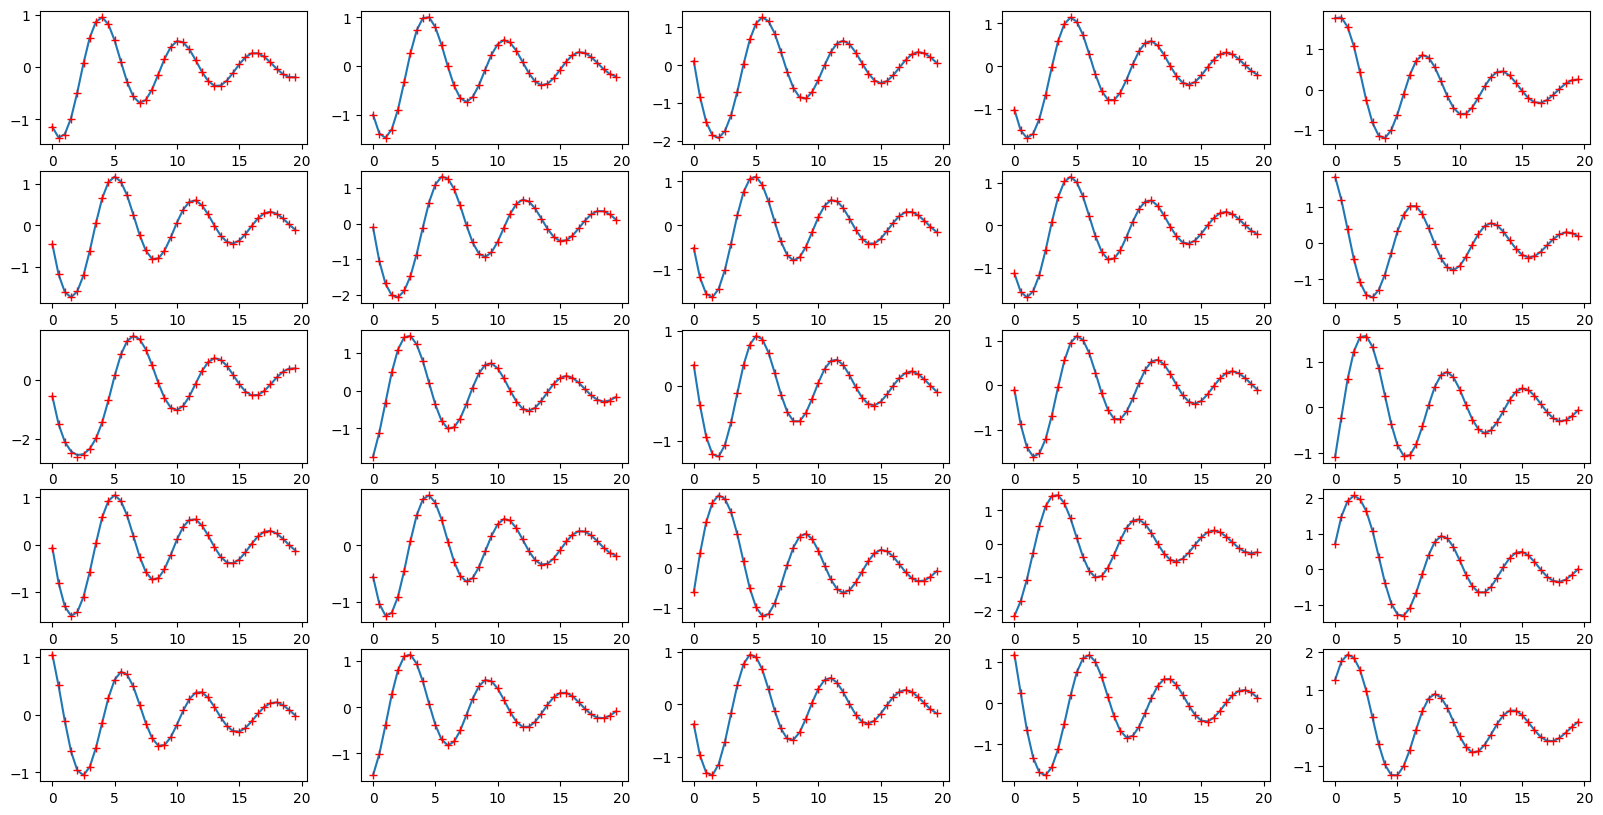

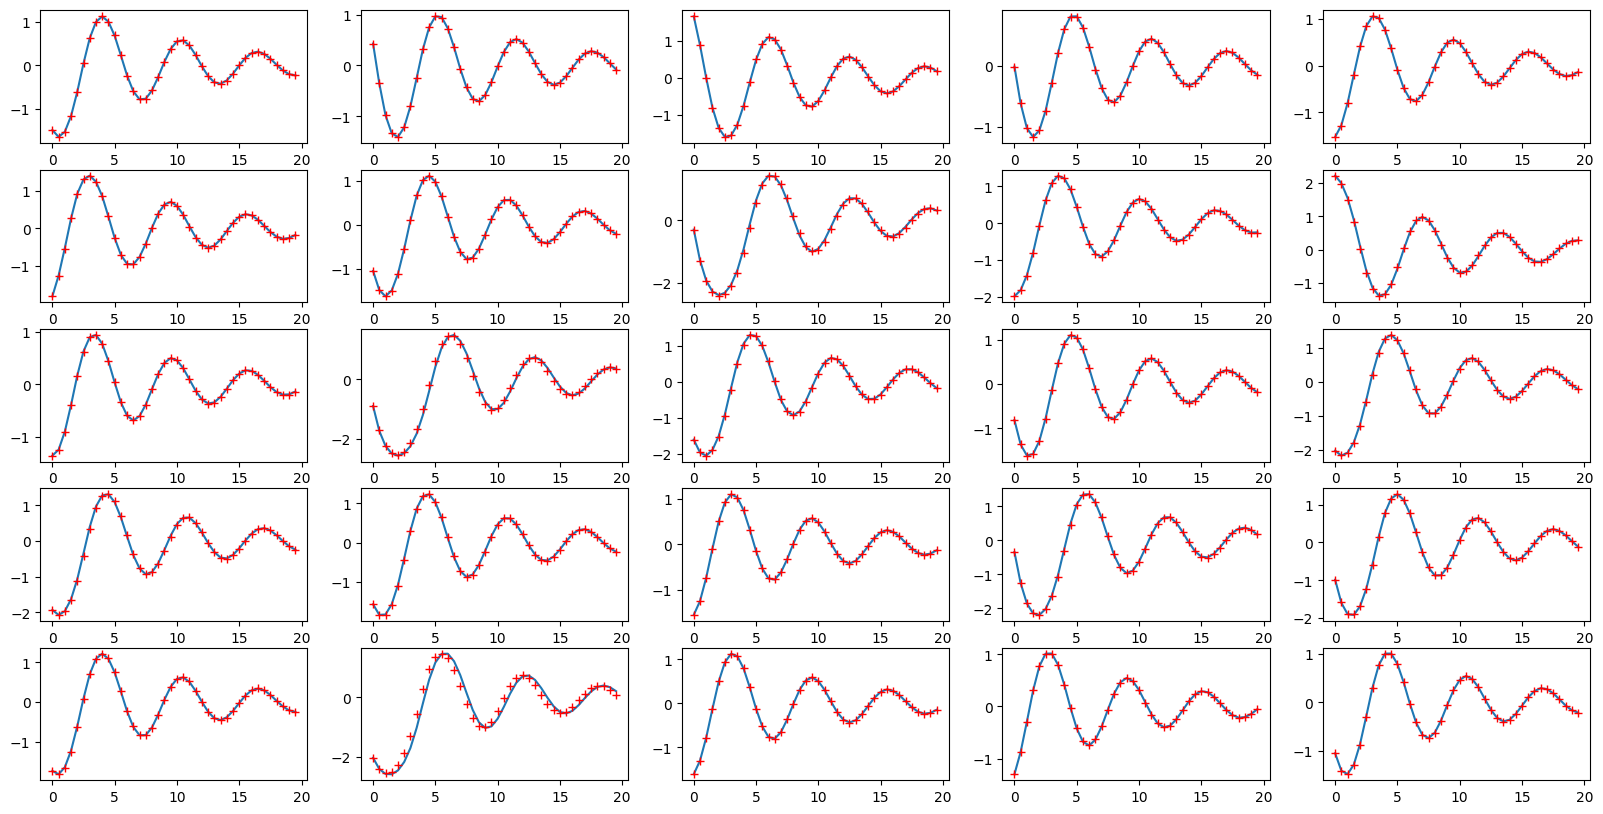

In [ ]:
# The code below plots the predicted values

## # pred contains
## pred = ...

plt.figure()
plt.rcParams["figure.figsize"] = [20, 10]

# Get batch data for plotting (re-fetch if needed for device compatibility)
plot_batch = next(iter(train_loader))
plot_batch_test = next(iter(test_loader))

# Get predictions for plotting
with torch.no_grad():
    y0_plot = plot_batch["states"][:, 0, :].to(device) # Corrected: get initial state (all dimensions) for each batch
    t_plot = plot_batch["t"][0].to(device)
    pred_plot = forecaster_net(y0_plot, t_plot)

    y0_plot_test = plot_batch_test["states"][:, 0, :].to(device) # Corrected for test data as well
    t_plot_test = plot_batch_test["t"][0].to(device)
    pred_plot_test = forecaster_net(y0_plot_test, t_plot_test)

p = pred_plot.detach().cpu().numpy()
ptest = pred_plot_test.detach().cpu().numpy()

# Determine grid size based on batch size
batch_size = min(plot_batch["states"].shape[0], 25)
grid_size = int(np.ceil(np.sqrt(batch_size)))
if grid_size > 5:
    grid_size = 5

fig, axs = plt.subplots(grid_size, grid_size)
for i in range(grid_size):
    for j in range(grid_size):
        idx = i * grid_size + j
        if idx < batch_size:
            axs[i, j].plot(
                plot_batch["t"][idx].cpu().numpy(),
                plot_batch["states"][idx, :, 0].cpu().numpy(), # Plot theta
                plot_batch["t"][idx].cpu().numpy(),
                p[idx, 0, :],
                "r+",
            )

fig, axs = plt.subplots(grid_size, grid_size)
for i in range(grid_size):
    for j in range(grid_size):
        idx = i * grid_size + j
        if idx < batch_size:
            axs[i, j].plot(
                plot_batch_test["t"][idx].cpu().numpy(),
                plot_batch_test["states"][idx, :, 0].cpu().numpy(), # Plot theta
                plot_batch_test["t"][idx].cpu().numpy(),
                ptest[idx, 0, :],
                "r+",
            )



# Bonus: see [this paper](https://proceedings.neurips.cc/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf) [1]
Experiment Neural ODE for other applications:
- **Replacing residual networks with ODEs for supervised learning** (see section 3 in paper), using the adjoint method.
- **Application for irregularly-sampled time series** (see section 5 in the paper).


[1] **Neural Ordinary Differential Equations.**
Ricky T. Q. Chen, Yulia Rubanova, Jesse Bettencourt, David K. Duvenaud.
NeurIPS 2018.

<!--bibtex

@inproceedings{nODE-NEURIPS2018,
 author = {Chen, Ricky T. Q. and Rubanova, Yulia and Bettencourt, Jesse and Duvenaud, David K},
 booktitle = {Advances in Neural Information Processing Systems},
 editor = {S. Bengio and H. Wallach and H. Larochelle and K. Grauman and N. Cesa-Bianchi and R. Garnett},
 pages = {},
 publisher = {Curran Associates, Inc.},
 title = {Neural Ordinary Differential Equations},
 url = {https://proceedings.neurips.cc/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf},
 volume = {31},
 year = {2018}
}

... Other Bibtex entries go here.

-->

<!--bibtex

@inproceedings{nODE-NEURIPS2018,
 author = {Chen, Ricky T. Q. and Rubanova, Yulia and Bettencourt, Jesse and Duvenaud, David K},
 booktitle = {Advances in Neural Information Processing Systems},
 editor = {S. Bengio and H. Wallach and H. Larochelle and K. Grauman and N. Cesa-Bianchi and R. Garnett},
 pages = {},
 publisher = {Curran Associates, Inc.},
 title = {Neural Ordinary Differential Equations},
 url = {https://proceedings.neurips.cc/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf},
 volume = {31},
 year = {2018}
}

... Other Bibtex entries go here.

-->

Neural ODE pour la classification

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint_adjoint as odeint

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import time


In [ ]:
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4467, 0.4398, 0.4066),
        std=(0.2603, 0.2566, 0.2713)
    )
])

transform_test = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(96),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4467, 0.4398, 0.4066),
        std=(0.2603, 0.2566, 0.2713)
    )
])

trainset = torchvision.datasets.STL10(
    root="./data", split="train", download=True, transform=transform_train
)
testset = torchvision.datasets.STL10(
    root="./data", split="test", download=True, transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



100%|██████████| 2.64G/2.64G [04:24<00:00, 9.99MB/s]


In [ ]:
class ODEFunc(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t, x):
        return self.net(x)


class ODEBlock(nn.Module):
    def __init__(self, odefunc, tol=1e-3):
        super().__init__()
        self.odefunc = odefunc
        self.integration_time = torch.tensor([0., 1.])
        self.tol = tol

    def forward(self, x):
        self.integration_time = self.integration_time.to(x)
        out = odeint(
            self.odefunc,
            x,
            self.integration_time,
            rtol=self.tol,
            atol=self.tol
        )
        return out[1]


class ODE_STL10(nn.Module):
    def __init__(self):
        super().__init__()

        self.downsampling = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )

        self.odefunc = ODEFunc(256)
        self.odeblock = ODEBlock(self.odefunc, tol=1e-3)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.downsampling(x)
        x = self.odeblock(x)
        x = self.classifier(x)
        return x


model = ODE_STL10().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100. * correct / total



In [ ]:
train_losses = []
test_accuracies = []

epochs = 3

for epoch in range(epochs):
    start = time.time()

    loss = train_epoch(model, trainloader)
    acc = evaluate(model, testloader)

    train_losses.append(loss)
    test_accuracies.append(acc)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss: {loss:.4f} | "
        f"Test Acc: {acc:.2f}% | "
        f"Time: {time.time() - start:.1f}s"
    )



In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss", color="tab:blue")
ax1.plot(train_losses, label="Train Loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Test Accuracy (%)", color="tab:red")
ax2.plot(test_accuracies, label="Test Accuracy", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

fig.tight_layout()
plt.title("Training Loss and Test Accuracy (ODE-Net, STL-10)")
plt.show()

Latent Neural ODE pour séries temporelles irrégulières

In [ ]:
def generate_spiral(n_points=100, noise_std=0.1, clockwise=True):
    t = np.linspace(0, 4 * np.pi, n_points)
    if clockwise:
        x = t * np.cos(t)
        y = t * np.sin(t)
    else:
        x = t * np.cos(-t)
        y = t * np.sin(-t)

    data = np.stack([x, y], axis=1)
    data += noise_std * np.random.randn(*data.shape)
    return t, data

def generate_dataset(n_samples=1000, n_points=100):
    data = []
    for i in range(n_samples):
        clockwise = i < n_samples // 2
        t, traj = generate_spiral(n_points, clockwise=clockwise)
        data.append((t, traj))
    return data

dataset = generate_dataset()

def subsample_trajectory(t, x, n_obs):
    idx = np.sort(np.random.choice(len(t), n_obs, replace=False))
    return t[idx], x[idx]

class RecognitionRNN(nn.Module):
    def __init__(self, obs_dim=2, hidden_dim=25, latent_dim=4):
        super().__init__()
        self.rnn = nn.GRU(obs_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        # x: (T, B, obs_dim)
        _, h = self.rnn(x.flip(0))
        h = h.squeeze(0)
        return self.fc_mu(h), self.fc_logvar(h)

class LatentODEFunc(nn.Module):
    def __init__(self, latent_dim=4, hidden_dim=20):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, t, z):
        return self.net(z)

class Decoder(nn.Module):
    def __init__(self, latent_dim=4, hidden_dim=20, obs_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, obs_dim)
        )

    def forward(self, z):
        return self.net(z)

class LatentODE(nn.Module):
    def __init__(self):
        super().__init__()
        self.recognition = RecognitionRNN()
        self.odefunc = LatentODEFunc()
        self.decoder = Decoder()

    def forward(self, t_obs, x_obs, t_all):
        mu, logvar = self.recognition(x_obs)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z0 = mu + eps * std

        zt = odeint(self.odefunc, z0, t_all)
        xt = self.decoder(zt)
        return xt, mu, logvar

def elbo_loss(x_pred, x_true, mu, logvar):
    recon = ((x_pred - x_true) ** 2).mean()
    kl = -0.5 * torch.mean(1 + logvar - mu**2 - logvar.exp())
    return recon + kl

model = LatentODE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


NameError: name 'torch' is not defined

In [ ]:
epochs = 200
n_obs = 30

for epoch in range(epochs):
    total_loss = 0.0

    for t, x in random.sample(dataset, 100):
        t_obs, x_obs = subsample_trajectory(t, x, n_obs)

        t_obs = torch.tensor(t_obs, dtype=torch.float32).to(device)
        x_obs = torch.tensor(x_obs, dtype=torch.float32).to(device)

        t_all = torch.tensor(t, dtype=torch.float32).to(device)

        x_obs = x_obs.unsqueeze(1)  # (T, 1, 2)

        optimizer.zero_grad()
        x_pred, mu, logvar = model(t_obs, x_obs, t_all)
        loss = elbo_loss(
            x_pred.squeeze(1),
            torch.tensor(x, dtype=torch.float32).to(device),
            mu, logvar
        )
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {total_loss:.4f}")



--- Training Latent ODE Autoencoder on Fashion MNIST ---
Epoch 1/10 | Loss: 0.6690
Epoch 2/10 | Loss: 0.6159
Epoch 3/10 | Loss: 0.6084
Epoch 4/10 | Loss: 0.6055
Epoch 5/10 | Loss: 0.6036
Epoch 6/10 | Loss: 0.6023
Epoch 7/10 | Loss: 0.6012
Epoch 8/10 | Loss: 0.6002
Epoch 9/10 | Loss: 0.5995
Epoch 10/10 | Loss: 0.5989

--- Latent ODE Autoencoder Training Complete ---



--- Training Latent ODE Autoencoder on Spiral Data ---
Epoch 100/500 | Loss: 16.315670
Epoch 200/500 | Loss: 13.621162
Epoch 300/500 | Loss: 11.828675
Epoch 400/500 | Loss: 8.577738
Epoch 500/500 | Loss: 5.322554

--- Spiral Latent ODE Autoencoder Training Complete ---


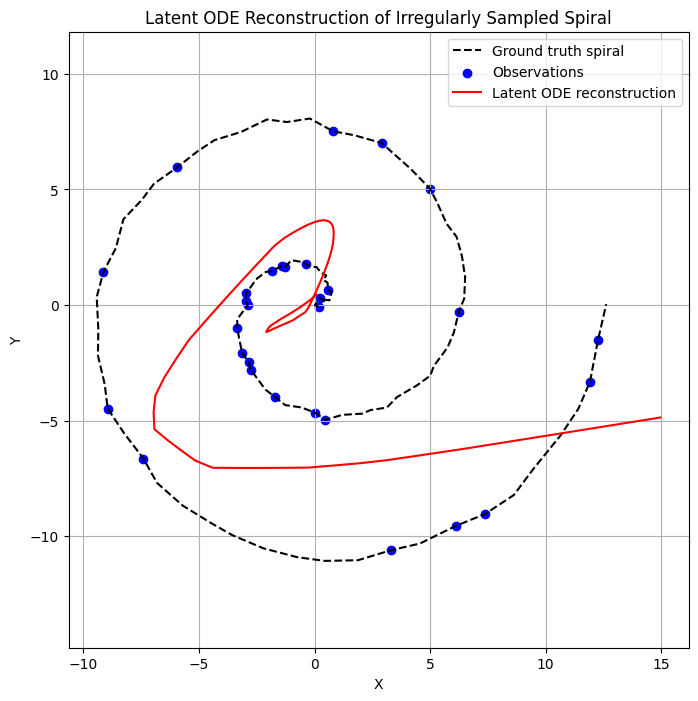

In [ ]:
def plot_example(model, trajectory):
    model.eval()
    t, x = trajectory
    t_obs, x_obs = subsample_trajectory(t, x, 30)

    t_all = torch.tensor(t, dtype=torch.float32).to(device)
    x_obs = torch.tensor(x_obs, dtype=torch.float32).unsqueeze(1).to(device)

    with torch.no_grad():
        x_pred, _, _ = model(t_obs, x_obs, t_all)

    x_pred = x_pred.squeeze(1).cpu().numpy()

    plt.figure(figsize=(5, 5))
    plt.plot(x[:, 0], x[:, 1], 'k--', label="Ground Truth")
    plt.scatter(x_obs[:, 0].cpu(), x_obs[:, 1].cpu(), c='red', label="Observed")
    plt.plot(x_pred[:, 0], x_pred[:, 1], 'blue', label="Latent ODE")
    plt.legend()
    plt.title("Latent ODE reconstruction & extrapolation")
    plt.show()


In [ ]:
plot_example(model, random.choice(dataset))